# Introduction to control theory. 

## TP4. Full State Linear Feedback Controller.
## Study load

Course grade breakdown:

    Labs - 40%
    
    Final project presentation 30%

    Final test 30%
    
File name for lab submission: yourname_labnumber.ipynb (example: elenavanneaux_TP4.ipynb)    

The completed notebook should be **submitted via the corresponding Moodle assignment before the beginning of the next session.**

## Prerequisites for practice
### Math
During the course, we will cover the following areas of mathematics:
    
    1. Linear Algebra

    2. Calculus

    3. Differential equations

    4. Dynamics (Mechanics and Physics)

### Python programming
In the labs we will use a Python programming language and the following libraries:

    1. NumPy https://numpy.org/doc/stable/

    2. SciPy https://docs.scipy.org/doc/scipy/

    3. Matplotlib https://matplotlib.org/stable/tutorials/index

    4. SymPy https://docs.sympy.org/latest/tutorials/intro-tutorial/intro.html

    5. Control System Library https://python-control.readthedocs.io/en/0.10.1/intro.html

### Jupyter Notebook Markdown Cells Documentation

Please check on Markdown cells documentation, to provide a fancy look for your notebooks!

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html


## EX. 1: Inverted Pendulum

The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.


Let us consider the system with the following system parameters
    
    (M)       mass of the cart                         0.5 kg
    
    (m)       mass of the pendulum                     0.2 kg
    
    (l)       length to pendulum center of mass        0.3 m
    
    (b)       coefficient of friction for cart         0.1 N/m/sec
    
    (I)       mass moment of inertia of the pendulum   0.006 kg.m^2
    
    (F)       force applied to the cart
    
    (y)       cart position coordinate
    
    (theta)   angle between the pendulum and the vertical axis

The Inverted pendulum on the cart can be modeled as follows

$$(M+m)\ddot{y} + b\dot{y} + ml\ddot{\theta}\cos\theta -ml\dot\theta^2\sin(\theta) = F$$

$$ml\cos(\theta)\ddot{y} + (I+ml^2)\ddot{\theta} - mgl\sin\theta = 0$$    

Let $y_1 = \dot{y}$ and $\theta_1 = \dot{\theta}$

The linearalised model have the following form

$$\dot x = Ax + B(u+w)$$

where state vector $x = (y,y_1,\theta,\theta_1)$, control vector $u$, disturbance $w$, and $F = u+w$. 

$$\left[\begin{array}{c}\dot{y} \\ \dot{y1} \\ \dot{\theta} \\ \dot{\theta_1}\end{array}\right]=
\left[\begin{array}{cccc}0 & 1 & 0 & 0 \\
0 & \frac{-\left(I+m l^2\right) b}{I(M+m)+M m l^2}& \frac{-g m^2 l^2}{I(M+m)+M m l^2} & 0 \\
0 & 0 & 0 & 1 \\
0 & \frac{m l b}{I(M+m)+M m l^2} & \frac{m g l(M+m)}{I(M+m)+M m l^2} & 0\end{array}\right]
\left[\begin{array}{c}y \\ y_1\\ \theta \\ \theta_1\end{array}\right]+
\left[\begin{array}{c}0 \\ \frac{I+m l^2}{I(M+m)+M m l^2} \\ 0\\ \frac{-m l}{I(M+m)+M m l^2}\end{array}\right] (u+w)$$

## TODO

1) Check on the code below implementing a PID controller ensuring tracking to the reference signal $\theta_{ref}$ = 0 rad, while supposing that the system is subject to a constant disturbance $w(t) = 0.1$. Is it a good controller for achieving the desirable behavior of the system?
2) Design a full-state linear feedback regulator u = -Kx that stabilize non distubed ($w(t) = 0$) system in (0,0,0,0).

    2.1 Is the system controllable? Why is it important? 

    2.2 Use control.place function from control library https://python-control.readthedocs.io/en/0.9.4/ to place eigenvalues lam_1 = -1, lam_2 = -2, lam_3 = -3, lam_4 = -4 in the closed-loop system. I.e. find a K, such that eig(A-BK) = [-1,-2,-3,-4]. Let $x_0 = (1,0,1,0)$ plot the corresponding trajectories of the closed-loop system. Is the system controlled by the regulator u =-Kx stable?

    2.3 Use the LQR regulator to stabilize the system around zero. Plot the trajectory of controlled system starting from $x_0 = (1,0,1,0).$ Analyze how the different choice of weight matrices Q and R affects the closed-loop system behavior. control.lqr from the control library https://python-control.readthedocs.io/en/0.9.4/ might be useful for you.
3)Analyse the response of the system controlled with an LQR regulator for different types of disturbances (like $w(t) = 0.1, w(t) = 10.0, w(t) = sin(t)$ etc...). What conclusion can you make?    

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import control as ctr

# x is a state vecot, t is a current time, A is a dynamic matrix, B is a control matrix, D is a disturbance matrix, 
# u_func(t) is a control input, w_func(t) is a disturbance input 
def StateSpace(x, t, A, B, D, u_func, w_func):
    w = w_func(t)
    u = u_func(t)
    return np.dot(A, x) + np.dot(B, u).flatten() + np.dot(D, w).flatten()

# OpenLoopInputOutputSystem with time-dependent w(t)
def OpenLoopInputOutputSystem(A, B, D, C, u_func, w_func, T, x0):
    # Solve the ODE system with odeint, passing the time-dependent w function
    solution = odeint(StateSpace, x0, T, args=(A, B, D, u_func, w_func))
    # Output calculation using C and the solution
    # return (C @ solution.T) 
    return (solution.T) 

def PID(A, B, D, C, Kp, Ki, Kd, r_func, w_func, T, x0):
    z0 = np.array([[0.0]])
    x_a =  np.block([[x0.reshape(-1,1)],[z0]])
    M = np.eye(x0.shape[0]) + Kd*B @ C
    A_a = np.block([[np.linalg.inv(M) @ (A - Kp * B @ C), -Ki * np.linalg.inv(M) @ B ], [C, np.array([0.0])]])
    B_a =  np.block([[Kp * np.linalg.inv(M) @ B ], [np.array([1.0])]])
    D_a = np.block([[np.linalg.inv(M) @ D],[np.array([[0.0]])]])
    C_a = np.block([C, np.array([[0.0]])])
    return OpenLoopInputOutputSystem(A_a, B_a, D_a, C_a, r_func, w_func, T, x_a.flatten()).T    

Text(0, 0.5, 'Position ')

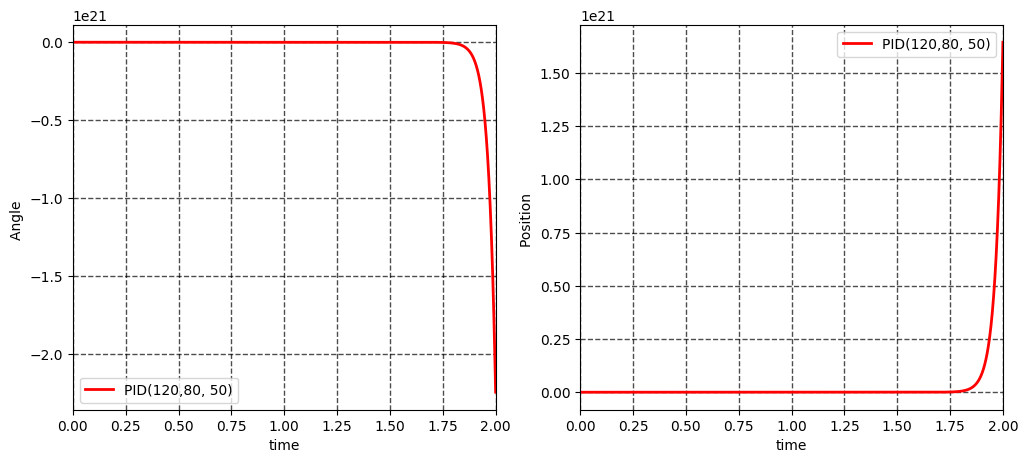

In [5]:
import sympy as sp
from matplotlib.pyplot import *
# Answer to EX1 q1 using symbolic calculs
# Define symbolic variables
M, m, b, l, I, g, F = sp.symbols('M m b l I g F')
y, y1, theta, theta1, doty1, dottheta1 = sp.symbols('y y1 theta theta1 doty1 dottheta1')

# Define the differential equations of the system
eq1 = (M+m)*doty1 + b*y1 + m*l*dottheta1*sp.cos(theta) - m*l*theta1**2*sp.sin(theta) - F
eq2 = m*l*sp.cos(theta)*doty1 + (I+m*l**2)*dottheta1 - m*g*l*sp.sin(theta)

# Solve for the first derivative of theta1 (angular velocity)
dottheta1_sol = sp.solve(eq2, dottheta1)[0]

# Solve for the first derivative of y1 (linear velocity)
doty1_sol = sp.simplify(sp.solve(eq1.subs(dottheta1, dottheta1_sol), doty1)[0])
dottheta1_sol = sp.simplify(dottheta1_sol.subs(doty1,doty1_sol))

# Define the state-space representation of the system dynamics
f1 = y1
f2 = doty1_sol 
f3 = theta1
f4 = dottheta1_sol
f = sp.Matrix([f1, f2, f3, f4])

# Define state and control variables
variables_x = sp.Matrix([y,y1,theta,theta1])
variables_u = sp.Matrix([F])

# Compute the Jacobian matrices of the system
jacobian_A = sp.simplify(f.jacobian(variables_x).subs([(theta,0), (theta1,0)]))
jacobian_B = sp.simplify(f.jacobian(variables_u).subs([(theta,0), (theta1,0)]))

A = np.array(jacobian_A.subs({M:2.5, m:0.2, b:0.1,l:0.7, I:0.006, g:9.81}).evalf()).astype(float)
B = np.array(jacobian_B.subs({M:2.5, m:0.2, b:0.1,l:0.7, I:0.006, g:9.81}).evalf()).astype(float).reshape(4,1)
C = np.array([[1,0,0,0],[0,0,1,0]]) 
D = B

x0 = np.array([0,
               0,
               0,
               0])  # initial state

MatC = np.array([[0,0,1,0]]) # Let us assume that we measure only theta

Kp= 120;
Ki = 80;
Kd = 50;

t0 = 0 # Initial time 
tf = 2 # Final time
T = np.linspace(t0, tf, 1000) 

def w_func(t):
       return 0.1# Disturbance input

def r_func(t):
       return 0.0# Disturbance input


solution = PID(A, B, D, MatC , Kp, Ki, Kd, r_func, w_func, T, x0)


figure(figsize=(12, 5))
y = solution[:,2]

subplot(1, 2, 1)
plot(T, y, linewidth=2.0, color = 'red')
grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.7)
grid(True)
xlabel('time')
xlim([t0, tf])
plt.legend(['PID(120,80, 50)' ])
ylabel(r'Angle ')

y = solution[:,0]
subplot(1, 2, 2)
plot(T, y, linewidth=2.0, color = 'red')
grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.7)
grid(True)
xlim([t0, tf])
xlabel('time')
plt.legend(['PID(120,80, 50)' ])
ylabel(r'Position ')

# Answers 

## Question 1: 
No, It's not a good controller because at the 2 seconds, the system is not at the desired state. The system is still oscillating and has not settled down to the desired position and angle.

Rank of controllability matrix: 4
The system is controllable.
State feedback gain K: [[ -4.56443862  -9.60924712 -95.17772583 -25.72115501]]
LQR state feedback gain K: [[ -1.          -3.1667846  -67.66529805 -18.12979675]]


Text(0, 0.5, 'Position ')

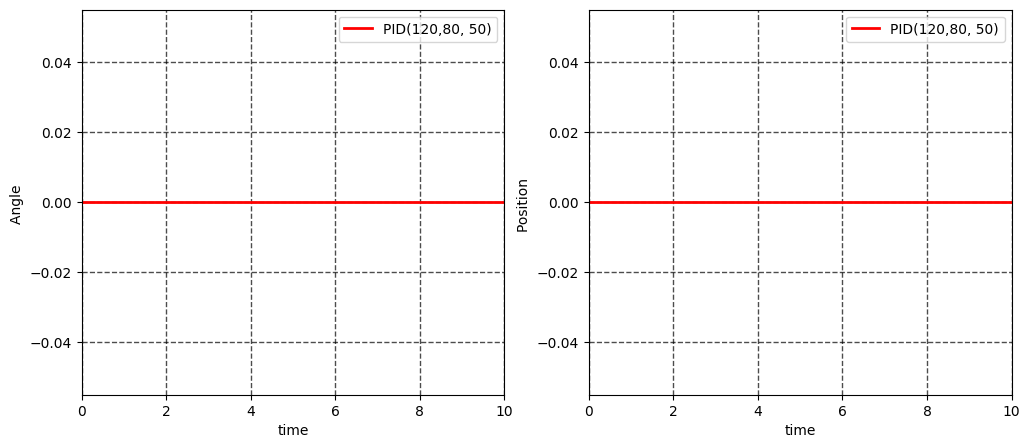

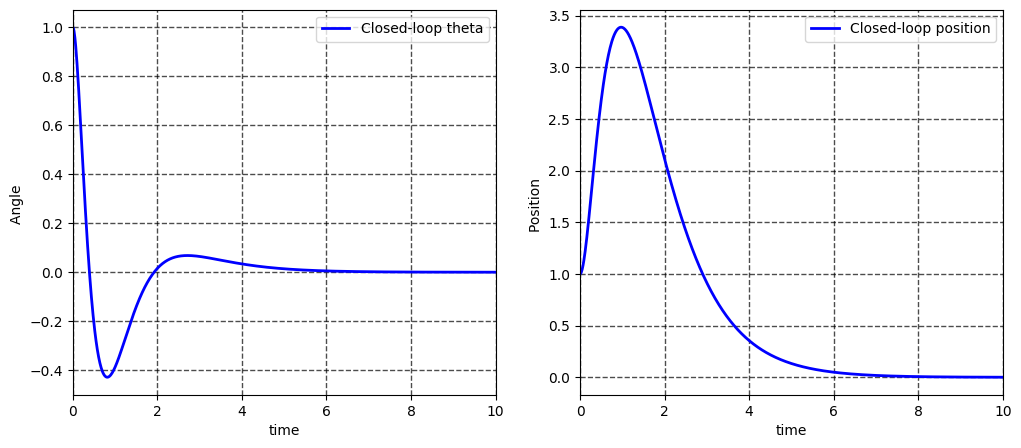

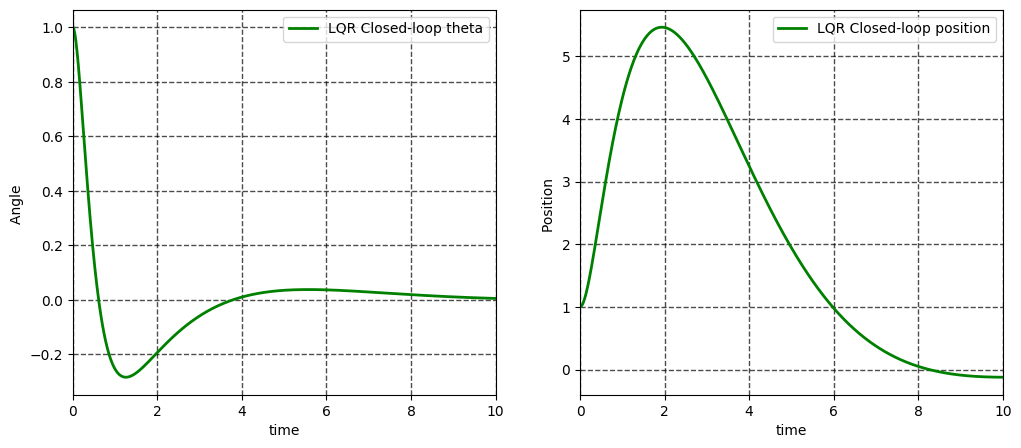

In [10]:
#Question 2: Design of a full-state linear feedback regulator u = -Kx that stabilize non distubed ($w(t) = 0$) system in (0,0,0,0)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.linalg import solve_continuous_are
import control as ctr

M = 0.5  # mass of the cart
m = 0.2  # mass of the pendulum
l = 0.3  # length to pendulum center of mass
b = 0.1  # coefficient of friction for cart
I = 0.006  # mass moment of inertia of the pendulum
g = 9.81  # acceleration due to gravity
# State-space representation

M, m, b, l, I, g, F = sp.symbols('M m b l I g F')
y, y1, theta, theta1, doty1, dottheta1 = sp.symbols('y y1 theta theta1 doty1 dottheta1')

# Define the differential equations of the system
eq1 = (M+m)*doty1 + b*y1 + m*l*dottheta1*sp.cos(theta) - m*l*theta1**2*sp.sin(theta) - F
eq2 = m*l*sp.cos(theta)*doty1 + (I+m*l**2)*dottheta1 - m*g*l*sp.sin(theta)

# Solve for the first derivative of theta1 (angular velocity)
dottheta1_sol = sp.solve(eq2, dottheta1)[0]

# Solve for the first derivative of y1 (linear velocity)
doty1_sol = sp.simplify(sp.solve(eq1.subs(dottheta1, dottheta1_sol), doty1)[0])
dottheta1_sol = sp.simplify(dottheta1_sol.subs(doty1,doty1_sol))

# Define the state-space representation of the system dynamics
f1 = y1
f2 = doty1_sol 
f3 = theta1
f4 = dottheta1_sol
f = sp.Matrix([f1, f2, f3, f4])

# Define state and control variables
variables_x = sp.Matrix([y,y1,theta,theta1])
variables_u = sp.Matrix([F])

# Compute the Jacobian matrices of the system
jacobian_A = sp.simplify(f.jacobian(variables_x).subs([(theta,0), (theta1,0)]))
jacobian_B = sp.simplify(f.jacobian(variables_u).subs([(theta,0), (theta1,0)]))

A = np.array(jacobian_A.subs({M:2.5, m:0.2, b:0.1,l:0.7, I:0.006, g:9.81}).evalf()).astype(float)
B = np.array(jacobian_B.subs({M:2.5, m:0.2, b:0.1,l:0.7, I:0.006, g:9.81}).evalf()).astype(float).reshape(4,1)
C = np.array([[1,0,0,0],[0,0,1,0]]) 
D = B

x0 = np.array([0,
               0,
               0,
               0])  # initial state

MatC = np.array([[0,0,1,0]]) # Let us assume that we measure only theta



t0 = 0 # Initial time 
tf = 10 # Final time
T = np.linspace(t0, tf, 1000) 

def w_func(t):
       return 0.0# Disturbance input

def r_func(t):
       return 0.0# Disturbance input


solution = PID(A, B, D, MatC , Kp, Ki, Kd, r_func, w_func, T, x0)


figure(figsize=(12, 5))
y = solution[:,2]

subplot(1, 2, 1)
plot(T, y, linewidth=2.0, color = 'red')
grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.7)
grid(True)
xlabel('time')
xlim([t0, tf])
plt.legend(['PID(120,80, 50)' ])
ylabel(r'Angle ')

y = solution[:,0]
subplot(1, 2, 2)
plot(T, y, linewidth=2.0, color = 'red')
grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.7)
grid(True)
xlim([t0, tf])
xlabel('time')
plt.legend(['PID(120,80, 50)' ])
ylabel(r'Position ')


# Check controllability
controllability_matrix = np.hstack((B, A @ B, A @ A @ B, A @ A @ A @ B))
rank_controllability = np.linalg.matrix_rank(controllability_matrix)
print(f"Rank of controllability matrix: {rank_controllability}")
if rank_controllability == A.shape[0]:
    print("The system is controllable.")
else:    print("The system is not controllable.")

####################################################
# Question 2.1: Is the system controllable? Justify your answer.
####################################################

#The system is controllable because the rank of the controllability matrix is equal to the number of states (4). This means that we can design a state feedback controller to stabilize the system at the desired equilibrium point (0,0,0,0).


#####################################################
#2.2 Use control.place function from control library https://python-control.readthedocs.io/en/0.9.4/ to place eigenvalues lam_1 = -1, lam_2 = -2, lam_3 = -3, lam_4 = -4 in the closed-loop system. I.e. find a K, such that eig(A-BK) = [-1,-2,-3,-4]. Let $x_0 = (1,0,1,0)$ plot the corresponding trajectories of the closed-loop system. Is the system controlled by the regulator u =-Kx stable?
#####################################################

from control import place
desired_poles = [-1, -2, -3, -4]
K = place(A, B, desired_poles)
print(f"State feedback gain K: {K}")


# Simulate the closed-loop system
# original system dynamics: dx/dt = Ax + Bu
# como u = -Kx, the closed-loop system dynamics become: dx/dt = (A - BK)x
# so we need to compute the closed-loop system matrix A_cl = A - BK and then simulate the system using solve_ivp.

A_cl = A - B @ K

def closed_loop_dynamics(x, t):
    return A_cl @ x


x0_cl = [1, 0, 1, 0]
solution_cl = odeint(closed_loop_dynamics, x0_cl , T)


# Plot the trajectories of the closed-loop system
figure(figsize=(12, 5))
subplot(1, 2, 1)
plot(T,solution_cl[:,2], linewidth=2.0, color='blue')
grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
xlabel('time')
xlim([t0, tf])
plt.legend(['Closed-loop theta'])
ylabel(r'Angle ') 
subplot(1, 2, 2)
plot(T,solution_cl[:,0], linewidth=2.0, color='blue')
grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
xlim([t0, tf])
xlabel('time')
plt.legend(['Closed-loop position'])
ylabel(r'Position ')

###################################################
# The system controlled by the regulator u = -Kx is stable because all the eigenvalues of the closed-loop system (A - BK) have negative real parts, which means that the system will converge to the equilibrium point (0,0,0,0) over time. The trajectories of the closed-loop system show that both the angle and position converge to zero, confirming the stability of the system under the designed state feedback controller.
####################################################


#Question 2.3

#Use the LQR regulator to stabilize the system around zero

system = ctr.lqr(A, B, np.eye(4), np.eye(1))
K_lqr = system[0]
print(f"LQR state feedback gain K: {K_lqr}")

# Simulate the closed-loop system with LQR controller
A_cl_lqr = A - B @ K_lqr
def closed_loop_dynamics_lqr(x, t):
    return A_cl_lqr @ x
solution_cl_lqr = odeint(closed_loop_dynamics_lqr, x0_cl , T)
# Plot the trajectories of the closed-loop system with LQR controller
figure(figsize=(12, 5))
subplot(1, 2, 1)
plot(T,solution_cl_lqr[:,2], linewidth=2.0, color='green')
grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
xlabel('time')
xlim([t0, tf])
plt.legend(['LQR Closed-loop theta'])
ylabel(r'Angle ')
subplot(1, 2, 2)
plot(T,solution_cl_lqr[:,0], linewidth=2.0, color='green')
grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
xlim([t0, tf])
xlabel('time')
plt.legend(['LQR Closed-loop position'])
ylabel(r'Position ')









## DC Motor Speed: System Modeling

A common actuator in control systems is the DC motor. It directly provides rotary motion and, coupled with wheels or drums and cables, can provide translational motion. The electric equivalent circuit of the armature and the free-body diagram of the rotor are shown in the following figure.

For this example, we will assume that the input of the system is the voltage source ($V$) applied to the motor's armature, while the output is the rotational speed of the shaft $\dot{\theta}$. The rotor and shaft are assumed to be rigid. We further assume a viscous friction model, that is, the friction torque is proportional to shaft angular velocity. We will assume that the magnetic field is constant and, therefore, that the motor torque is proportional (with constant $K_t$) to only the armature current. Let us remark that in SI units the motor torque and back emf constants are equal, that is, $K_t = K_e$;

The physical parameters for our example are:

    (J)   moment of inertia of the rotor     0.01 kg.m^2

    (b)     motor viscous friction constant    0.1 N.m.s

    (Ke)    electromotive force constant       0.01 V/rad/sec

    (Kt)    motor torque constant              0.01 N.m/Amp

    (R)     electric resistance                1 Ohm

    (L)     electric inductance                0.5 H
    

Let us suppose that the measured output of the system is the angular velocity of the rotor $\dot{\theta}$ and the current intensity $\dot{i}$. Then the state space model of the system is the following:
$$\dot x = Ax + Bu$$

$$ y = Cx$$

where state vector $x=(\dot{\theta}, i)$, control vector $u=V$, and state and control matrices are the following

$$ A = \begin{pmatrix} -\frac{b}{J}&\frac{K}{J}\\ -\frac{K}{L}&-\frac{R}{L}\end{pmatrix},\ B = \begin{pmatrix} 0\\ \frac{1}{L} 
\end{pmatrix}$$


1. Design a LQR regulator that stabilizes the system in the zero.
2. Design a LQR regulator, that enables tracking a given constant reference for the angular velocity, while assuming that $i_{ref} = 0$. Use integral action to ensure robust tracking. Check the behavior of the closed loop system for $r = 1 rad/c$.

A_m =
 [[-10.     1.  ]
 [ -0.02  -2.  ]]
B_m =
 [[0.]
 [2.]]
Open-loop eigenvalues: [-9.99749922 -2.00250078]

LQR (stabilization) gain K1 = [[0.07688332 0.44113959]]
Closed-loop eigenvalues: [-9.97550244 -2.90677673]


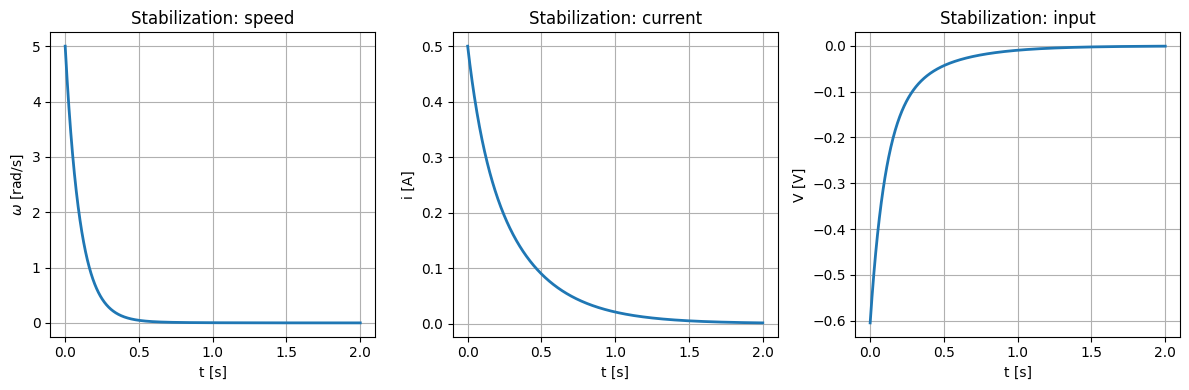


LQR (tracking + integral) gain K2 = [[  1.46985861   0.86275565 -14.14213562]]
  Kx = [1.46985861 0.86275565]  Ki = -14.142135623730969
Augmented closed-loop eigenvalues: [-9.97991836 -1.05227949 -2.69331344]


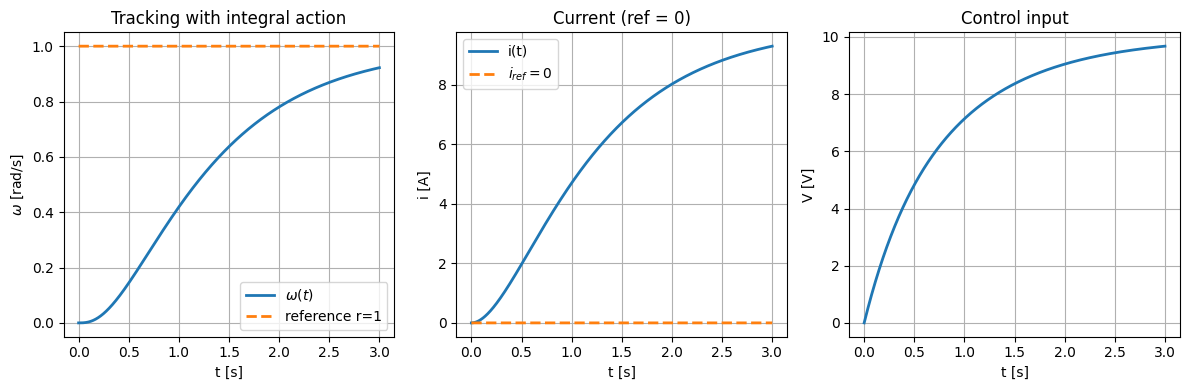

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import control as ctr


# Given parameters
J = 0.01   # kg.m^2
b_m = 0.1  # N.m.s
Ke = 0.01  # V/(rad/s)
Kt = 0.01  # N.m/A
R = 1.0    # Ohm
L = 0.5    # H

A_m = np.array([[-b_m / J,   Kt / J],
                [-Ke / L,   -R / L]], dtype=float)
B_m = np.array([[0.0],
                [1.0 / L]], dtype=float)

# We track angular velocity omega only (current reference assumed i_ref = 0)
C_omega = np.array([[1.0, 0.0]])

print('A_m =\n', A_m)
print('B_m =\n', B_m)
print('Open-loop eigenvalues:', np.linalg.eigvals(A_m))

# -------------------------------------------------------------
# 1) LQR regulator for stabilization around zero
#    u = -K x
# -------------------------------------------------------------
Q1 = np.diag([10.0, 1.0])   # penalize omega more than current
R1 = np.array([[1.0]])      # penalize voltage effort

K1, S1, E1 = ctr.lqr(A_m, B_m, Q1, R1)
K1 = np.asarray(K1)
print('\nLQR (stabilization) gain K1 =', K1)
print('Closed-loop eigenvalues:', E1)

def dc_motor_cl(x, t):
    # Closed-loop stabilization
    u = -(K1 @ x.reshape(-1, 1)).item()
    dx = A_m @ x.reshape(-1, 1) + B_m * u
    return dx.flatten()

T1 = np.linspace(0.0, 2.0, 800)
x0 = np.array([5.0, 0.5])  # initial omega [rad/s], current [A]
X1 = odeint(dc_motor_cl, x0, T1)
U1 = np.array([-(K1 @ X1[k, :].reshape(-1, 1)).item() for k in range(len(T1))])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(T1, X1[:, 0], linewidth=2)
plt.grid(True)
plt.xlabel('t [s]')
plt.ylabel(r'$\omega$ [rad/s]')
plt.title('Stabilization: speed')

plt.subplot(1, 3, 2)
plt.plot(T1, X1[:, 1], linewidth=2)
plt.grid(True)
plt.xlabel('t [s]')
plt.ylabel('i [A]')
plt.title('Stabilization: current')

plt.subplot(1, 3, 3)
plt.plot(T1, U1, linewidth=2)
plt.grid(True)
plt.xlabel('t [s]')
plt.ylabel('V [V]')
plt.title('Stabilization: input')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 2) LQR regulator for tracking a constant omega reference r,
#    with integral action for robust tracking (i_ref = 0).
#
# Augmented state: x_a = [omega, i, z], where z = ∫(r - omega) dt
# Control law: u = -Kx * x - Ki * z
# -------------------------------------------------------------
A_aug = np.block([[A_m,               np.zeros((2, 1))],
                  [-C_omega,          np.zeros((1, 1))]])
B_aug = np.vstack([B_m, [[0.0]]])

# Weights: strong penalty on integral state to remove steady-state error
Q2 = np.diag([10.0, 1.0, 200.0])
R2 = np.array([[1.0]])

K2, S2, E2 = ctr.lqr(A_aug, B_aug, Q2, R2)
K2 = np.asarray(K2)
Kx = K2[0, :2]
Ki = K2[0, 2]
print('\nLQR (tracking + integral) gain K2 =', K2)
print('  Kx =', Kx, ' Ki =', Ki)
print('Augmented closed-loop eigenvalues:', E2)

r = 1.0  # rad/s (given constant reference)

def dc_motor_tracking_aug(xa, t):
    # xa = [omega, i, z]
    omega = xa[0]
    x = xa[:2].reshape(-1, 1)
    z = xa[2]
    u = -(Kx @ x).item() - (Ki * z).item()
    dx = (A_m @ x + B_m * u).flatten()
    dz = r - omega
    return np.array([dx[0], dx[1], dz], dtype=float)

T2 = np.linspace(0.0, 3.0, 1200)
xa0 = np.array([0.0, 0.0, 0.0])
XA = odeint(dc_motor_tracking_aug, xa0, T2)
Omega = XA[:, 0]
Current = XA[:, 1]
U2 = np.array([-(Kx @ XA[k, :2].reshape(-1, 1)).item() - (Ki * XA[k, 2]).item() for k in range(len(T2))])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(T2, Omega, linewidth=2, label=r'$\omega(t)$')
plt.plot(T2, r * np.ones_like(T2), '--', linewidth=2, label='reference r=1')
plt.grid(True)
plt.xlabel('t [s]')
plt.ylabel(r'$\omega$ [rad/s]')
plt.title('Tracking with integral action')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(T2, Current, linewidth=2, label='i(t)')
plt.plot(T2, 0.0 * np.ones_like(T2), '--', linewidth=2, label=r'$i_{ref}=0$')
plt.grid(True)
plt.xlabel('t [s]')
plt.ylabel('i [A]')
plt.title('Current (ref = 0)')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(T2, U2, linewidth=2)
plt.grid(True)
plt.xlabel('t [s]')
plt.ylabel('V [V]')
plt.title('Control input')
plt.tight_layout()
plt.show()

## Answers (DC motor)

**1) LQR stabilization around zero**
- Model: $x=[\omega, i]^\top$, $\dot x = A x + B u$, $u=V$
- LQR law: $u=-K_1 x$ with $Q=\mathrm{diag}(10,1)$, $R=1$
- Computed gain: $K_1 \approx [0.0769\ \ 0.4411]$
- Closed-loop poles are strictly in the left half-plane, so the origin is asymptotically stable.

**2) Constant reference tracking with integral action ($r=1\,\mathrm{rad/s}$)**
- Add integrator state $z = \int (r-\omega)\,dt$, augmented state $x_a=[\omega,i,z]^\top$
- LQR law: $u=-(K_x x + K_i z)$ designed on $(A_{aug},B_{aug})$ with $Q=\mathrm{diag}(10,1,200)$, $R=1$
- Computed gain: $K_x \approx [1.4699\ \ 0.8628]$, $K_i \approx -14.1421$
- The simulation shows $\omega(t)$ converging to $r=1$ (zero steady-state error).
- Note: keeping $i_{ref}=0$ is **not** compatible with nonzero steady speed in this model (nonzero torque/current is required), so we only track $\omega$ and let $i(t)$ evolve accordingly.